# Import Packages

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
color = sns.color_palette()
from tqdm import tqdm
from urllib.parse import urlparse
pd.set_option("display.max_colwidth", 200)
import warnings
warnings.filterwarnings('ignore')
from sklearn.pipeline import FeatureUnion
from sklearn.model_selection import cross_val_predict, GroupKFold
from sklearn.pipeline import FeatureUnion
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import BernoulliNB, ComplementNB, MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from scipy.sparse import hstack
%matplotlib inline

# Load Datasets

In [2]:
df = pd.read_csv("./dataset/dataset_crawl_070526.csv")

#### Basic Exploration

In [3]:
df.shape

(201465, 5)

In [4]:
df.head()

,Webpage_id,Domain,Url,Tag,Crawled_at
0,1,abcnews.go.com,https://abcnews.go.com/live,non-gambling,2026-04-27 15:16:52
1,2,abcnews.go.com,https://abcnews.go.com/international,non-gambling,2026-04-27 15:16:54
2,3,abcnews.go.com,https://abcnews.go.com/lifestyle,non-gambling,2026-04-27 15:16:56
3,4,abcnews.go.com,https://abcnews.go.com/us,non-gambling,2026-04-27 15:16:58
4,5,abcnews.go.com,https://abcnews.go.com/business,non-gambling,2026-04-27 15:17:04


In [5]:
df['Tag'].unique()

<StringArray>
['non-gambling', 'gambling']
Length: 2, dtype: str

In [6]:
df[df['Tag'] == 'non-gambling'].head()

,Webpage_id,Domain,Url,Tag,Crawled_at
0,1,abcnews.go.com,https://abcnews.go.com/live,non-gambling,2026-04-27 15:16:52
1,2,abcnews.go.com,https://abcnews.go.com/international,non-gambling,2026-04-27 15:16:54
2,3,abcnews.go.com,https://abcnews.go.com/lifestyle,non-gambling,2026-04-27 15:16:56
3,4,abcnews.go.com,https://abcnews.go.com/us,non-gambling,2026-04-27 15:16:58
4,5,abcnews.go.com,https://abcnews.go.com/business,non-gambling,2026-04-27 15:17:04


In [7]:
df[df['Tag'] == 'gambling'].head()

,Webpage_id,Domain,Url,Tag,Crawled_at
101313,101314,03oncuuy7j.slotmantapviral.com,https://03oncuuy7j.slotmantapviral.com/mobile/home,gambling,2026-05-06 10:01:42
101314,101315,03oncuuy7j.slotmantapviral.com,https://03oncuuy7j.slotmantapviral.com/desktop/home,gambling,2026-05-06 10:01:44
101315,101316,03oncuuy7j.slotmantapviral.com,https://03oncuuy7j.slotmantapviral.com/desktop/hot-games,gambling,2026-05-06 10:01:46
101316,101317,03oncuuy7j.slotmantapviral.com,https://03oncuuy7j.slotmantapviral.com/desktop/slots/pragmatic,gambling,2026-05-06 10:01:51
101317,101318,03oncuuy7j.slotmantapviral.com,https://03oncuuy7j.slotmantapviral.com/desktop/slots/jili,gambling,2026-05-06 10:01:53


# Target Exploration

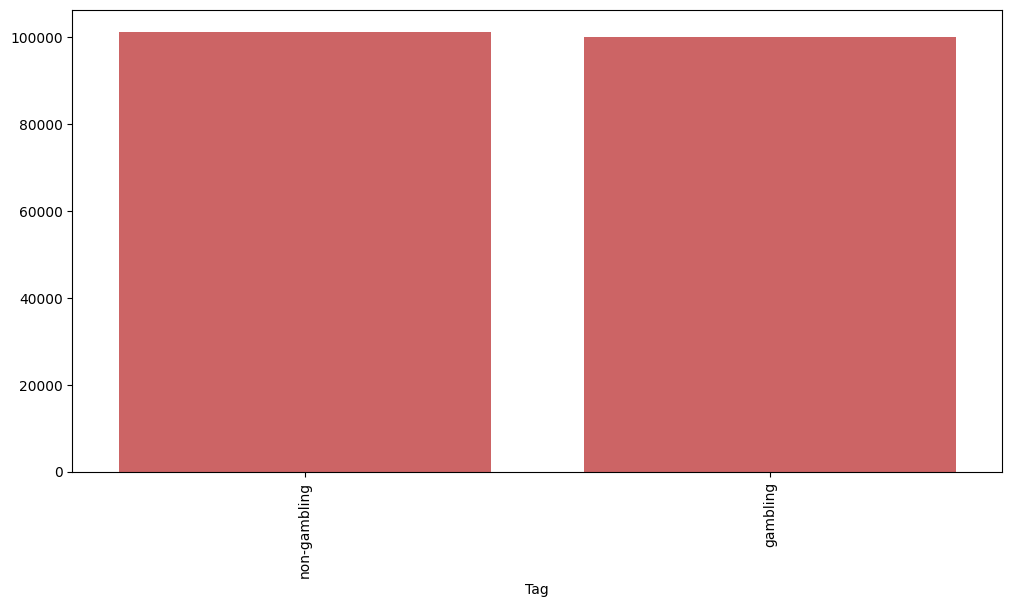

In [8]:
cnt_tag = df['Tag'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=cnt_tag.index, y=cnt_tag.values, alpha=0.8, color=color[3])
plt.xticks(rotation='vertical')
plt.show()

# Understanding the Common Words Used in the URLs: WordCloud

In [9]:
all_words = ' '.join([text for text in df['Url']])
from wordcloud import WordCloud
wordcloud = WordCloud(width=800, height=500, random_state=21, max_font_size=110).generate(all_words)

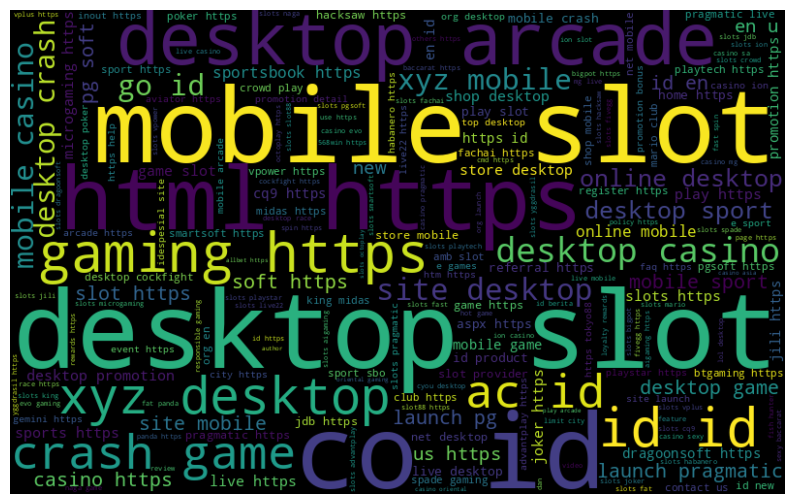

In [10]:
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

#### Word Cloud for the Tag: Non-Gambling

In [11]:
all_words = ' '.join([text for text in df[df['Tag'] == 'non-gambling']['Url']])
wordcloud = WordCloud(width=800, height=500, random_state=21,
             max_font_size=110).generate(all_words)

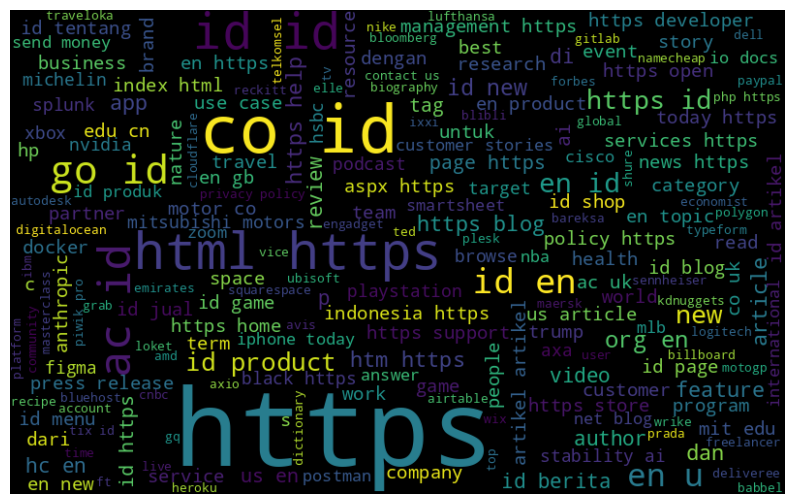

In [12]:
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

#### Word Cloud for the Tag: Gambling

In [13]:
all_words = ' '.join([text for text in df[df['Tag'] == 'gambling']['Url']])
wordcloud = WordCloud(width=800, height=500, random_state=21,
             max_font_size=110).generate(all_words)

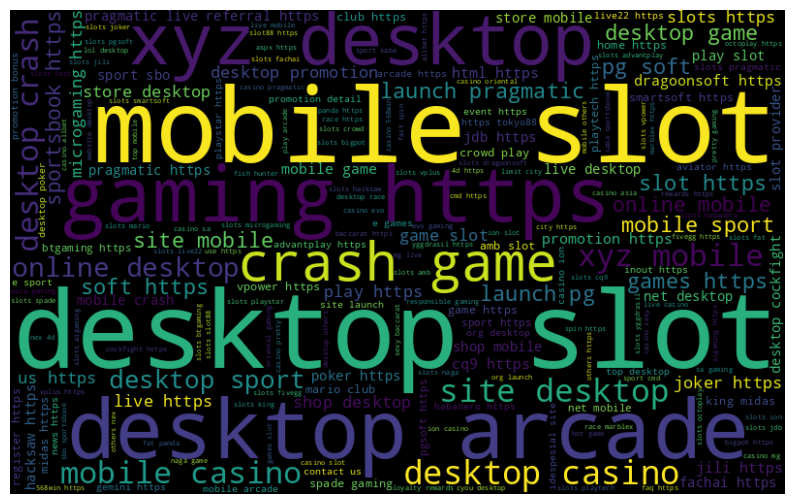

In [14]:
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

# Feature Extraction

In [15]:
def clean_url(df):
    df["Url"] = df["Url"].str.replace("/", " ")
    df["Url"] = df["Url"].str.replace("-", " ")
    df["Url"] = df["Url"].str.replace("%20", " ")
    df["Url"] = df["Url"].str.replace("https:", "")
    df["Url"] = df["Url"].str.replace("http:", "")
    return df

In [16]:
df = clean_url(df)

In [17]:
df.head(5)

,Webpage_id,Domain,Url,Tag,Crawled_at
0,1,abcnews.go.com,abcnews.go.com live,non-gambling,2026-04-27 15:16:52
1,2,abcnews.go.com,abcnews.go.com international,non-gambling,2026-04-27 15:16:54
2,3,abcnews.go.com,abcnews.go.com lifestyle,non-gambling,2026-04-27 15:16:56
3,4,abcnews.go.com,abcnews.go.com us,non-gambling,2026-04-27 15:16:58
4,5,abcnews.go.com,abcnews.go.com business,non-gambling,2026-04-27 15:17:04


### Bag-of-Words Features

In [18]:
# Word and character BOW on URLs
vec_bow = CountVectorizer(ngram_range=(1, 3), min_df=400)
vec_bow.fit(df['Url'])
Url_bow = vec_bow.transform(df['Url'])

#### Train Test Split

In [19]:
# Replicate train/test split strategy for cross validation
df["target_str"] = df["Domain"].astype(str) + '_' + df["Tag"].astype(str)
cvlist = list(GroupKFold(5).split(df, groups=df["target_str"]))

In [20]:
df["target_str"].head()

0    abcnews.go.com_non-gambling
1    abcnews.go.com_non-gambling
2    abcnews.go.com_non-gambling
3    abcnews.go.com_non-gambling
4    abcnews.go.com_non-gambling
Name: target_str, dtype: str

In [21]:
X = Url_bow

In [22]:
TAG_DICT = {"non-gambling":1, "gambling": 2}

In [23]:
df['target'] = df.Tag.map(TAG_DICT)
y = df["target"].values

# Model Building and Model Validation

In [24]:
def cv_score(ml_model, df):
    i = 1
    cv_scores = []
    X = df
    
    # Custom Cross validation based on group KFold
    for df_index,test_index in cvlist:
        print('n{} of Group kfold {}'.format(i,5))
        xtr,xvl = X[df_index],X[test_index]
        ytr,yvl = y[df_index],y[test_index]
            
        # Define model for fitting on the training set for each fold
        model = ml_model
        model.fit(xtr, ytr)
        pred_probs = model.predict_proba(xvl)
        label_preds = np.argmax(pred_probs, axis=1) + 1
        
        # Calculate scores for each fold and print
        score = f1_score(yvl, label_preds, average="weighted")
        sufix = ""
        msg = ""
        msg += "Weighted F1 Score: {}".format(score)
        print("{}".format(msg))
         
         # Save scores
        cv_scores.append(score)
        i+=1
    return cv_scores

#### Naive Bayes

In [25]:
cv_score(MultinomialNB(alpha=.01), Url_bow)

n1 of Group kfold 5
Weighted F1 Score: 0.9470127327746707
n2 of Group kfold 5
Weighted F1 Score: 0.9625394903617005
n3 of Group kfold 5
Weighted F1 Score: 0.9503092861481967
n4 of Group kfold 5
Weighted F1 Score: 0.9424345352255928
n5 of Group kfold 5
Weighted F1 Score: 0.9557794589233433


[0.9470127327746707,
 0.9625394903617005,
 0.9503092861481967,
 0.9424345352255928,
 0.9557794589233433]

#### Character N-Grams

In [26]:
# Word and character BOW on URLs
vec1 = CountVectorizer(analyzer='char', ngram_range=(1, 5), min_df=500)
vec2 = CountVectorizer(analyzer='word', ngram_range=(1, 3), min_df=400)
vec_bow = FeatureUnion([("char", vec1), ("word", vec2)])
vec_bow.fit(df['Url'])
Url_bow = vec_bow.transform(df['Url'])

In [27]:
cv_score(MultinomialNB(alpha=.01), Url_bow)

n1 of Group kfold 5
Weighted F1 Score: 0.9644954425307366
n2 of Group kfold 5
Weighted F1 Score: 0.9766374390201704
n3 of Group kfold 5
Weighted F1 Score: 0.9605586443172366
n4 of Group kfold 5
Weighted F1 Score: 0.9654249499753191
n5 of Group kfold 5
Weighted F1 Score: 0.9717182470883727


[0.9644954425307366,
 0.9766374390201704,
 0.9605586443172366,
 0.9654249499753191,
 0.9717182470883727]

#### TFIDF Features

In [28]:
# Word and character TFIDF on URLs
vec1 = TfidfVectorizer(analyzer='char', ngram_range=(1, 5), min_df=500)
vec2 = TfidfVectorizer(analyzer='word', ngram_range=(1, 3), min_df=400)
vec_tfidf = FeatureUnion([("char", vec1), ("word", vec2)])
vec_tfidf.fit(df['Url'])
Url_tfidf = vec_tfidf.transform(df['Url'])

In [29]:
nb = cv_score(MultinomialNB(alpha=.01), Url_tfidf)

n1 of Group kfold 5
Weighted F1 Score: 0.9669070817782365
n2 of Group kfold 5
Weighted F1 Score: 0.9779240104076793
n3 of Group kfold 5
Weighted F1 Score: 0.9668927626039769
n4 of Group kfold 5
Weighted F1 Score: 0.967453094037276
n5 of Group kfold 5
Weighted F1 Score: 0.9752880477071957


#### Logistic Regression

In [30]:
log_reg = cv_score(LogisticRegression(C=0.1,class_weight="balanced"), Url_tfidf)

n1 of Group kfold 5
Weighted F1 Score: 0.9690530320369422
n2 of Group kfold 5
Weighted F1 Score: 0.9836338436635718
n3 of Group kfold 5
Weighted F1 Score: 0.9750192793040724
n4 of Group kfold 5
Weighted F1 Score: 0.9685938955050588
n5 of Group kfold 5
Weighted F1 Score: 0.98197971834716


#### Tree Based Methods

In [31]:
dtree = cv_score(DecisionTreeClassifier(min_samples_leaf=25, min_samples_split=25), Url_tfidf)

n1 of Group kfold 5
Weighted F1 Score: 0.939672108691579
n2 of Group kfold 5
Weighted F1 Score: 0.9548038606027172
n3 of Group kfold 5
Weighted F1 Score: 0.9363417222251118
n4 of Group kfold 5
Weighted F1 Score: 0.9154286608808999
n5 of Group kfold 5
Weighted F1 Score: 0.9584165720641696


#### Random Forest

In [32]:
rf_params = {'random_state': 0, 'n_jobs': -1, 'n_estimators': 100, 'max_depth': 50, 'n_jobs': -1}
rf = cv_score(RandomForestClassifier(**rf_params), Url_tfidf)

n1 of Group kfold 5
Weighted F1 Score: 0.9751332543126169
n2 of Group kfold 5
Weighted F1 Score: 0.9832166930479614
n3 of Group kfold 5
Weighted F1 Score: 0.9734932183534023
n4 of Group kfold 5
Weighted F1 Score: 0.963252657564066
n5 of Group kfold 5
Weighted F1 Score: 0.9814487041990153


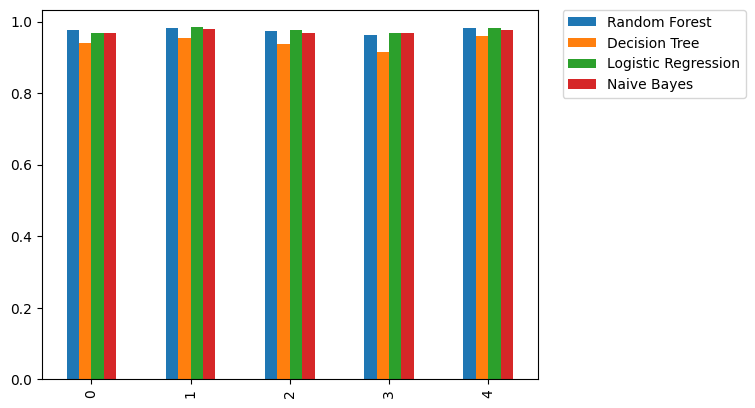

In [33]:
results_df = pd.DataFrame({'Random Forest':rf, 'Decision Tree': dtree, 'Logistic Regression': log_reg, 'Naive Bayes':nb})
results_df.plot(y=["Random Forest", "Decision Tree","Logistic Regression","Naive Bayes"], kind="bar")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()